# Personal Loan Acceptance Prediction
## Objective
### The objective of this project is to predict whether a customer will accept a personal loan offer using machine learning techniques.

In [37]:
# importing libraries
import pandas as pd
import numpy as npc
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score
# Loading dataset using pandas
df = pd.read_csv("bank.csv")
# Basic data exploration
print("Shape of Dataset:")
print(df.shape)
print("\nColumn Names:")
print(df.columns)
print("\nData types:")
print(df.info())
print("\nFirst 5 rows of dataset:")
print(df.head())

Shape of Dataset:
(11162, 17)

Column Names:
Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'deposit'],
      dtype='object')

Data types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null

**Missing Values**

In [22]:
print(df.isnull().sum())

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64


There is no missing value in the dataset

### Exploratory Data Analysis(EDA)
EDA is performed to visualize patterns and relationships in the data

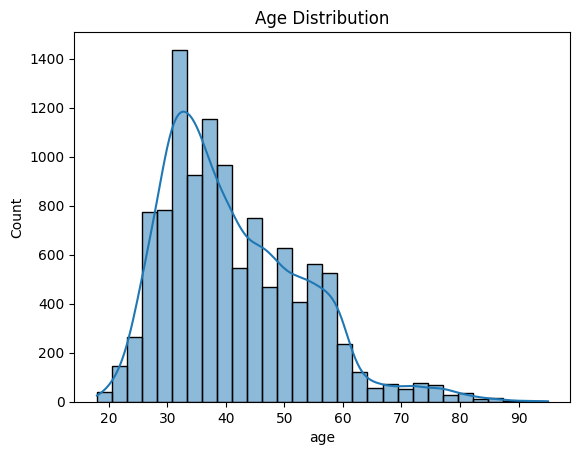

In [38]:
sns.histplot(df['age'], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

**Job Distribution**
This plot shows the number of customers in each profession.

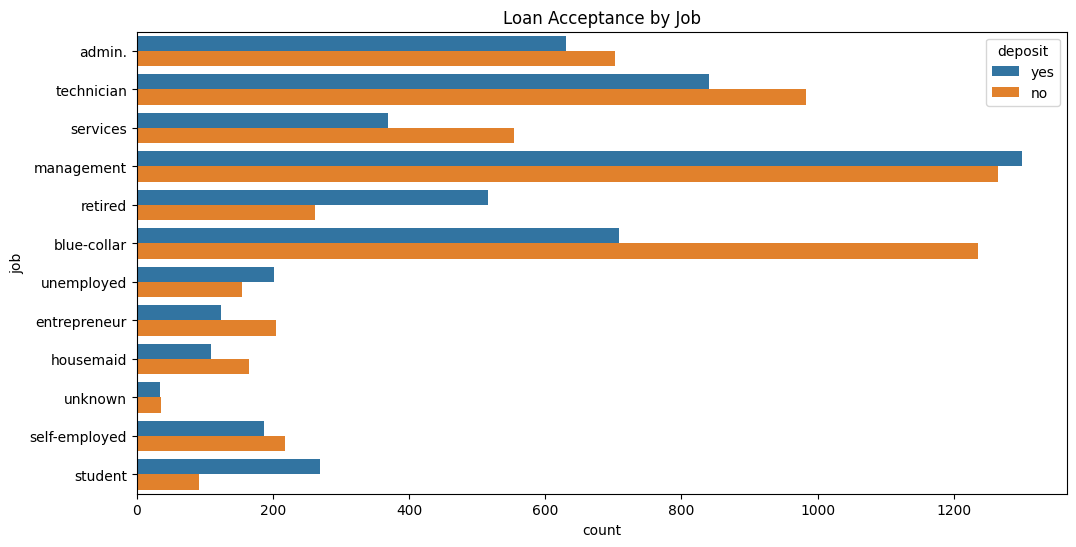

In [39]:
plt.figure(figsize=(12,6))
sns.countplot(y='job', hue='deposit', data=df)
plt.title("Loan Acceptance by Job")
plt.show()

This graph compares loan acceptance among different material groups

**Loan Acceptance by Material Status through Countplot**

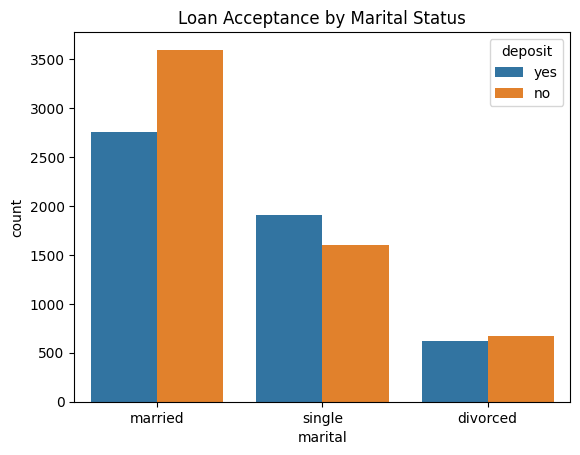

In [40]:
sns.countplot(x='marital', hue='deposit', data=df)
plt.title("Loan Acceptance by Marital Status")
plt.show()

**Loan Acceptance by Age Through Boxplot**

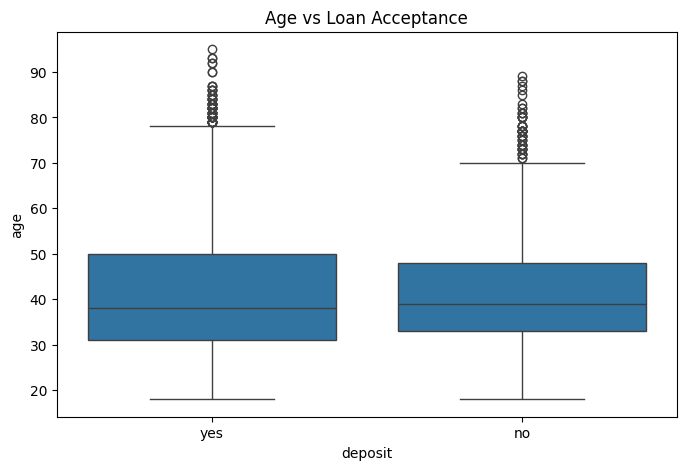

In [42]:
plt.figure(figsize=(8,5))
sns.boxplot(x='deposit', y='age', data=df)
plt.title("Age vs Loan Acceptance")
plt.show()

### Checking the values of Target Variables

In [43]:
print(df['deposit'].value_counts())

deposit
no     5873
yes    5289
Name: count, dtype: int64


### Data Preprocessing
Machine learning models cannot understand text values directly, so categorical columns are converted into numeric form.

In [45]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])
        print("\nDataset after encoding:")
        print(df)

       age  job  marital  education  ...  pdays  previous  poutcome  deposit
0       59    0        1          1  ...     -1         0         3        1
1       56    0        1          1  ...     -1         0         3        1
2       41    9        1          1  ...     -1         0         3        1
3       55    7        1          1  ...     -1         0         3        1
4       54    0        1          2  ...     -1         0         3        1
...    ...  ...      ...        ...  ...    ...       ...       ...      ...
11157   33    1        2          0  ...     -1         0         3        0
11158   39    7        1          1  ...     -1         0         3        0
11159   32    9        2          1  ...     -1         0         3        0
11160   43    9        1          1  ...    172         5         0        0
11161   34    9        1          1  ...     -1         0         3        0

[11162 rows x 17 columns]


### Features and Target Variables

In [48]:
X = df.drop('deposit', axis=1)
y = df['deposit']
#spliting train, test data
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42, stratify=y)

### Feature Scaling
 Scaling standardizes numeric values

In [49]:
scaler = MinMaxScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

It will improve Logistic Regression performance

### Train Logistic Regression Model

In [50]:
lr_model = LogisticRegression()

lr_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


The model learns patterns from training data.

### Predictions

In [52]:
y_pred = lr_model.predict(X_test)

## Model Evaluation


### Confusion Matrix

In [53]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[966, 209],
       [241, 817]])

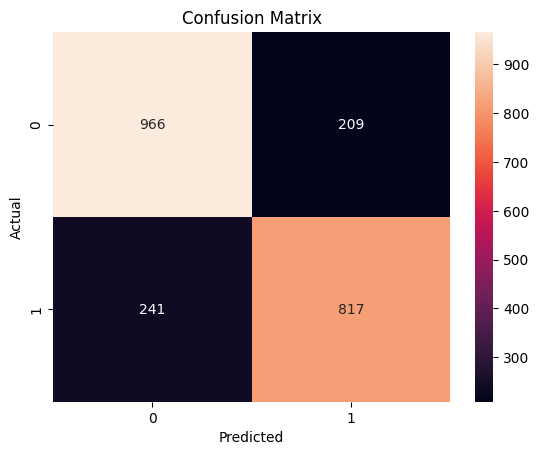

In [54]:
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [56]:
print("LogisticRegression Accuracy:",
      accuracy_score(y_test, y_pred))

LogisticRegression Accuracy: 0.7984773846842812


### Classification Report

In [57]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.82      0.81      1175
           1       0.80      0.77      0.78      1058

    accuracy                           0.80      2233
   macro avg       0.80      0.80      0.80      2233
weighted avg       0.80      0.80      0.80      2233



Feature Importance

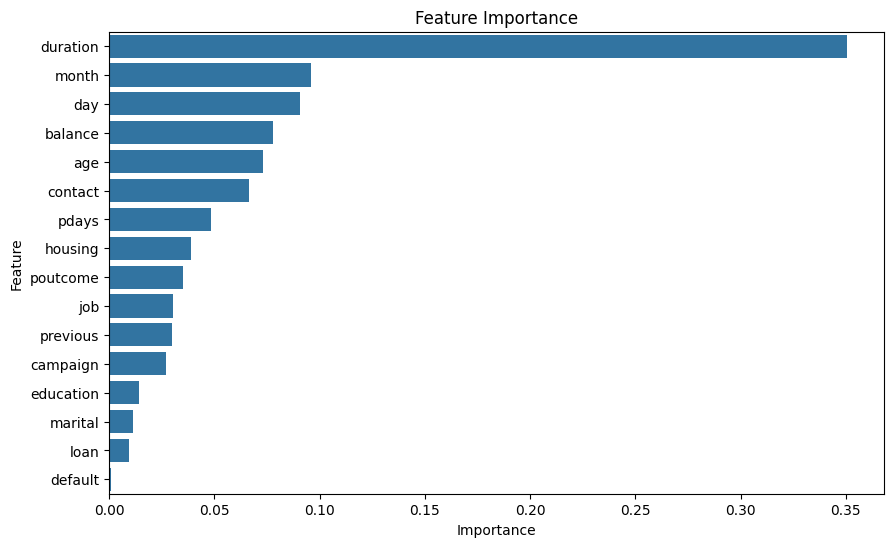

In [59]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_model.feature_importances_
})

importance = importance.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=importance)
plt.title("Feature Importance")
plt.show()

Feature importance was used to identify which variables have the strongest influence on predicting personal loan acceptance.
The results showed that duration had the highest importance, meaning the length of the last contact with the customer plays the most significant role in determining whether a customer will accept the loan offer.
After that, month and day of contact also showed relatively high importance, indicating that the timing of communication has an impact on customer response behavior.
Other important features included balance, followed by age, which also contribute to predicting customer decisions but with less influence compared to contact-related features. Overall, the analysis suggests that customer engagement during the campaign (especially contact duration and timing) is more influential than demographic factors in predicting loan acceptance.

# Model Performance after removing outliers

In [60]:
numeric_cols = ["age", "balance", "duration", "campaign"]

for col in numeric_cols:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df = df[(df[col] >= lower) & (df[col] <= upper)]

In [63]:
X = df.drop('deposit', axis=1)
y = df['deposit']
#spliting train, test data
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42, stratify=y)
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [64]:
y_pred = lr_model.predict(X_test)

In [74]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix after removing outliers:\n", cm)

Confusion Matrix after removing outliers:
 [[806 178]
 [184 605]]


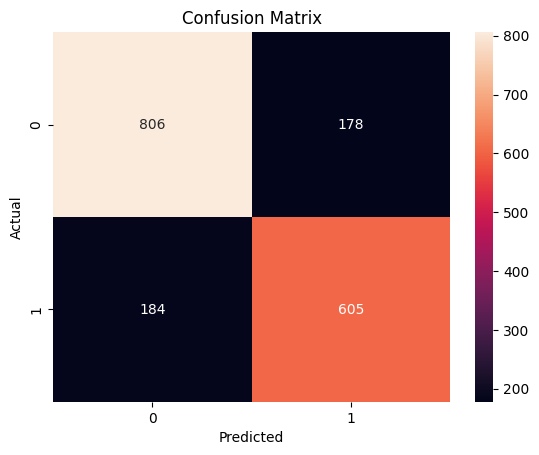

In [66]:
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [71]:
print("LogisticRegression Accuracy after removing outliers:",
      accuracy_score(y_test, y_pred))

LogisticRegression Accuracy after removing outliers: 0.7958262831359278


In [70]:
print("Classification report after removing outliers:",classification_report (y_test, y_pred))

Classification report after removing outliers:               precision    recall  f1-score   support

           0       0.81      0.82      0.82       984
           1       0.77      0.77      0.77       789

    accuracy                           0.80      1773
   macro avg       0.79      0.79      0.79      1773
weighted avg       0.80      0.80      0.80      1773



# Conclusion
In this project, a machine learning model was developed to predict which customers are likely to accept a personal loan offer using the Bank Marketing Dataset.
Exploratory Data Analysis (EDA) was performed to understand key customer attributes such as age, job, and marital status. Data preprocessing steps including encoding and feature scaling were applied to prepare the dataset for modeling.
A Logistic Regression model was trained to perform classification. Initially, the model achieved moderate performance. However, after applying outlier removal, the model performance improved, indicating that extreme values were negatively affecting learning.
After removing outliers, the model achieved an accuracy of 79.5%, along with a more balanced confusion matrix, showing improved predictive capability.
Overall, this project demonstrated how data cleaning (especially outlier removal) can significantly improve model performance, along with providing meaningful business insights into customer loan acceptance behavior.